In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from cmdstanpy import CmdStanModel

sns.set(style="whitegrid")
np.random.seed(42)


In [4]:
df = pd.read_csv("WritingStudyFastSlow_long.csv")

# Split condition into variables
df["hand"] = df["condition"].apply(lambda x: 1 if x.startswith("ND") else 0)
df["speed"] = df["condition"].apply(lambda x: 1 if "slow" in x else 0)
df["interaction"] = df["hand"] * df["speed"]

# Log transform
df["log_RT"] = np.log(df["RT"])

# Encode indices for Stan
df["participant_idx"] = df["participant"].astype("category").cat.codes + 1
df["char_idx"] = df["char"].astype("category").cat.codes + 1


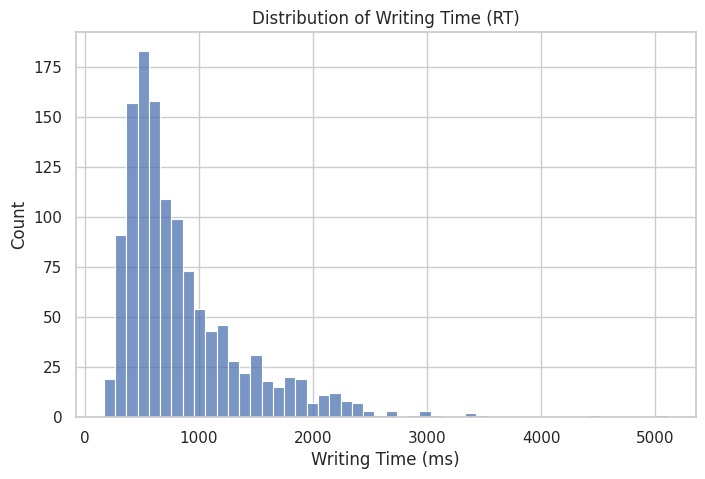

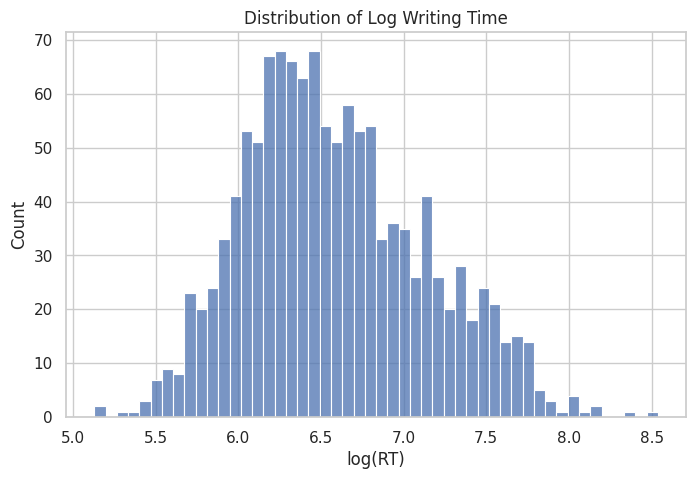

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["RT"], bins=50)
plt.title("Distribution of Writing Time (RT)")
plt.xlabel("Writing Time (ms)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["log_RT"], bins=50)
plt.title("Distribution of Log Writing Time")
plt.xlabel("log(RT)")
plt.ylabel("Count")
plt.show()


In [6]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


In [7]:
def make_stan_data(data):
    return {
        "N": len(data),
        "J": data["participant_idx"].nunique(),
        "K": data["char_idx"].nunique(),
        "participant": data["participant_idx"].values,
        "char": data["char_idx"].values,
        "hand": data["hand"].values,
        "speed": data["speed"].values,
        "interaction": data["interaction"].values,
        "y": data["log_RT"].values,
    }

train_data = make_stan_data(train_df)


In [ ]:
model = CmdStanModel(stan_file="handwriting.stan")

fit = model.sample(
    data=train_data,
    chains=4,
    iter_sampling=1000,
    iter_warmup=1000
)

print(fit.summary())


16:10:04 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]




In [ ]:
posterior = fit.draws_pd()
n_samples = len(posterior)

# Extract parameters
alpha_participant = posterior[[f"alpha_participant[{i+1}]" for i in range(train_data["J"])]].values
alpha_char = posterior[[f"alpha_char[{i+1}]" for i in range(train_data["K"])]].values

beta_hand = posterior["beta_hand"].values
beta_speed = posterior["beta_speed"].values
beta_interaction = posterior["beta_interaction"].values
sigma = posterior["sigma"].values


In [ ]:
train_participant = train_df["participant_idx"].values - 1
train_char = train_df["char_idx"].values - 1

test_participant = test_df["participant_idx"].values - 1
test_char = test_df["char_idx"].values - 1


In [ ]:
y_rep = []

for s in range(200):
    mu = (
        alpha_participant[s, train_participant]
        + alpha_char[s, train_char]
        + beta_hand[s] * train_df["hand"].values
        + beta_speed[s] * train_df["speed"].values
        + beta_interaction[s] * train_df["interaction"].values
    )

    y_sim = np.random.normal(mu, sigma[s])
    y_rep.append(y_sim)

# Plot PPC
plt.figure(figsize=(8,5))
plt.hist(train_df["log_RT"], bins=50, alpha=0.5, label="Observed Data")

for i, sim in enumerate(y_rep[:20]):
    if i == 0:
        plt.hist(sim, bins=50, alpha=0.1, color="red", label="Simulated Data (Posterior)")
    else:
        plt.hist(sim, bins=50, alpha=0.1, color="red")

plt.title("Posterior Predictive Check (log RT)")
plt.xlabel("log(RT)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
mu_test_samples = []

for s in range(n_samples):
    mu = (
        alpha_participant[s, test_participant]
        + alpha_char[s, test_char]
        + beta_hand[s] * test_df["hand"].values
        + beta_speed[s] * test_df["speed"].values
        + beta_interaction[s] * test_df["interaction"].values
    )
    mu_test_samples.append(mu)

mu_test_samples = np.array(mu_test_samples)

# Mean prediction
mu_test_mean = mu_test_samples.mean(axis=0)


In [ ]:
mse_log = np.mean((test_df["log_RT"].values - mu_test_mean) ** 2)
print("Test MSE (log scale):", mse_log)

pred_rt = np.exp(mu_test_mean)
actual_rt = test_df["RT"].values

mse_rt = np.mean((actual_rt - pred_rt) ** 2)
print("Test MSE (RT scale):", mse_rt)


In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(actual_rt, pred_rt, alpha=0.5, label="Predictions")

plt.plot(
    [actual_rt.min(), actual_rt.max()],
    [actual_rt.min(), actual_rt.max()],
    'r--',
    label="Perfect Prediction"
)

plt.title("Predicted vs Actual Writing Time")
plt.xlabel("Actual Writing Time (ms)")
plt.ylabel("Predicted Writing Time (ms)")
plt.legend()
plt.show()

In [ ]:
lower = np.percentile(mu_test_samples, 5, axis=0)
upper = np.percentile(mu_test_samples, 95, axis=0)

sorted_idx = np.argsort(mu_test_mean)

plt.figure(figsize=(8,5))

plt.errorbar(
    np.arange(len(mu_test_mean)),
    np.exp(mu_test_mean[sorted_idx]),
    yerr=[
        np.exp(mu_test_mean[sorted_idx]) - np.exp(lower[sorted_idx]),
        np.exp(upper[sorted_idx]) - np.exp(mu_test_mean[sorted_idx])
    ],
    fmt='o',
    alpha=0.5,
    label="Predicted RT with 95% Interval"
)

plt.title("Prediction Uncertainty (Sorted by Predicted RT)")
plt.xlabel("Test Observations (sorted)")
plt.ylabel("Predicted Writing Time (ms)")
plt.legend()
plt.show()

print(df["log_RT"].describe())
fit.summary().loc[["beta_hand","beta_speed","beta_interaction"]]

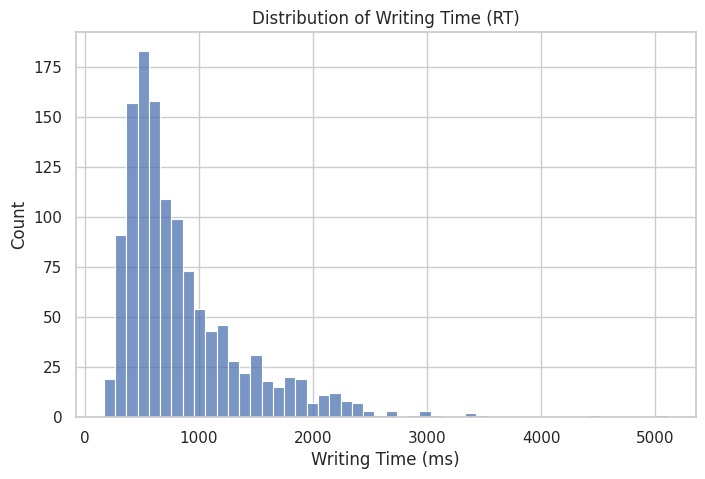

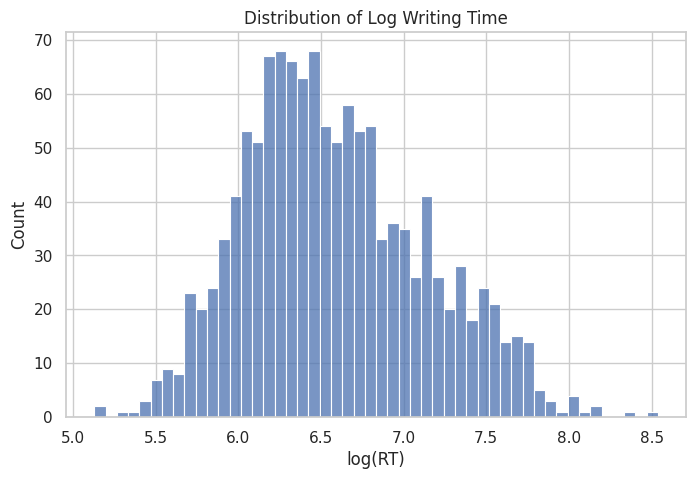

15:34:55 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]



chain 1:   5%|▌         | 100/2000 [00:00<00:07, 237.86it/s, (Warmup)]






chain 1:  10%|█         | 200/2000 [00:01<00:16, 107.52it/s, (Warmup)]



chain 1:  15%|█▌        | 300/2000 [00:03<00:21, 78.16it/s, (Warmup)] 

chain 1:  25%|██▌       | 500/2000 [00:05<00:17, 84.70it/s, (Warmup)]



chain 1:  30%|███       | 600/2000 [00:07<00:17, 79.20it/s, (Warmup)]


chain 1:  35%|███▌      | 700/2000 [00:08<00:16, 78.53it/s, (Warmup)]


chain 1:  40%|████      | 800/2000 [00:09<00:14, 82.70it/s, (Warmup)]







chain 1:  45%|████▌     | 900/2000 [00:10<00:14, 78.54it/s, (Warmup)]


chain 1:  50%|█████     | 1000/2000 [00:12<00:13, 73.91it/s, (Sampling)]


chain 1:  55%|█████▌    | 1100/2000 [00:13<00:10, 81.83it/s, (Sampling)]


chain 1:  60%|██████    | 1200/2000 [00:14<00:08, 89.51it/s, (Sampling)]

chain 1:  65%|██████▌   | 1300/2000 [00:14<00:06, 102.76it/s, (Sampli


15:35:16 - cmdstanpy - INFO - CmdStan done processing.
15:35:16 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'handwriting.stan', line 35, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'handwriting.stan', line 35, column 4 to column 66)
Consider re-running with show_console=True if the above output is unclear!



                              Mean      MCSE    StdDev       MAD           5%  \
lp__                   1049.250000  0.133581  4.712210  4.670630  1040.860000   
mu_participant            5.655700  0.021873  0.222884  0.221982     5.288740   
sigma_participant         0.166418  0.001053  0.026628  0.026899     0.128167   
alpha_participant[1]      5.469930  0.022164  0.223042  0.224839     5.105300   
alpha_participant[2]      5.725450  0.022047  0.223266  0.225221     5.348950   
alpha_participant[3]      5.704710  0.022175  0.223937  0.221898     5.337950   
alpha_participant[4]      5.956370  0.021891  0.223152  0.223322     5.592710   
alpha_participant[5]      5.623470  0.022001  0.223183  0.222958     5.255690   
alpha_participant[6]      5.703980  0.022163  0.222972  0.225244     5.339560   
alpha_participant[7]      5.721540  0.022026  0.223004  0.219486     5.357850   
alpha_participant[8]      5.487630  0.021995  0.222473  0.222454     5.122120   
alpha_participant[9]      5

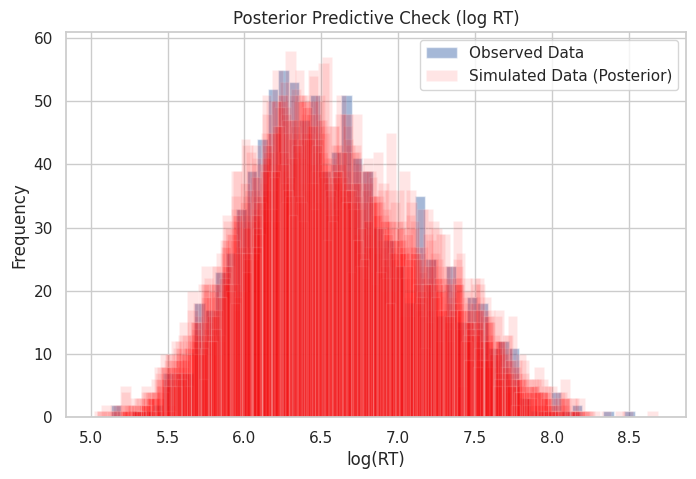

Test MSE (log scale): 0.051554164569661616
Test MSE (RT scale): 43897.57093248677


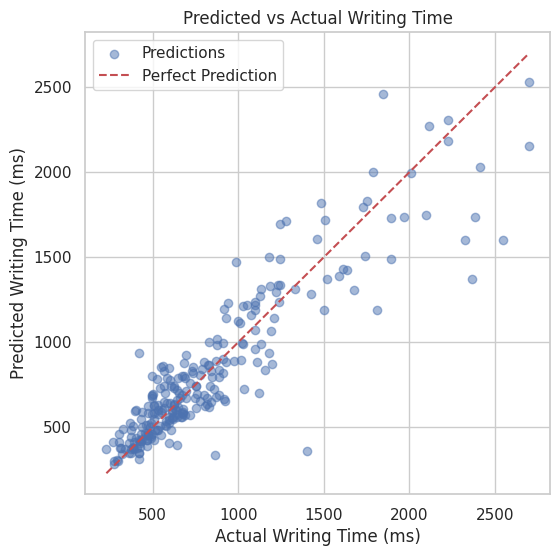

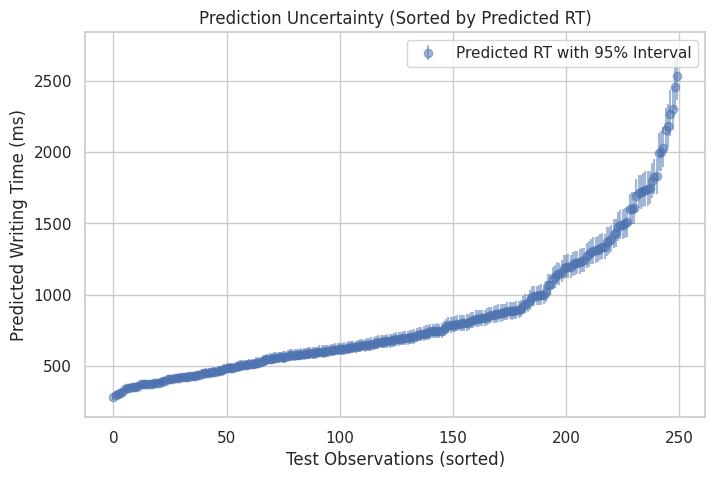

count    1247.000000
mean        6.585954
std         0.548422
min         5.129899
25%         6.180017
50%         6.514713
75%         6.946489
max         8.538172
Name: log_RT, dtype: float64


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
beta_hand,0.496752,0.000787,0.018867,0.018461,0.465502,0.496550,0.527808,573.164,876.253,14.9698,1.00592
beta_speed,0.396616,0.000839,0.019062,0.018983,0.365695,0.396036,0.428872,527.558,800.235,13.7787,1.00471
beta_interaction,0.326371,0.001186,0.026637,0.025950,0.281721,0.327190,0.369748,507.377,789.926,13.2516,1.00477
